# 01 · Data Check — Favorita Grocery Sales

Dieser Datensatz besteht aus **6 Dateien**, die zusammen das Verkaufsgeschehen von 54 ecuadorianischen Supermärkten (Corporación Favorita) zwischen 2013 und 2017 abbilden.

| Datei | Inhalt | Rolle |
|---|---|---|
| `transactions.csv` | Tägliche Transaktionen pro Store | **Zielgröße** |
| `stores.csv` | Metadaten zu jedem Store (Stadt, Typ, Cluster) | Join via `store_nbr` |
| `oil.csv` | Täglicher Ölpreis (Ecuador ist ölabhängig) | Exogener Regressor |
| `holidays_events.csv` | Ecuadorianische Feiertage & Events | Kalender-Features |
| `items.csv` | Produkt-Metadaten | Nur bei Item-Level relevant |
| `test.csv` | Vorhersagezeitraum 16.–31.08.2017 | Kaggle-Submission |

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
RAW = Path('..') / '02_data' / 'raw'

## 1 · Einlesen & erster Überblick

In [2]:
tx     = pl.read_csv(RAW / 'transactions.csv',    try_parse_dates=True)
stores = pl.read_csv(RAW / 'stores.csv')
oil    = pl.read_csv(RAW / 'oil.csv',             try_parse_dates=True)
hol    = pl.read_csv(RAW / 'holidays_events.csv', try_parse_dates=True)
items  = pl.read_csv(RAW / 'items.csv')

print('transactions:', tx.shape)
print('stores:      ', stores.shape)
print('oil:         ', oil.shape)
print('holidays:    ', hol.shape)
print('items:       ', items.shape)

transactions: (83488, 3)
stores:       (54, 5)
oil:          (1218, 2)
holidays:     (350, 6)
items:        (4100, 4)


## 2 · transactions.csv — Zielgröße

In [3]:
tx.head(10)

date,store_nbr,transactions
date,i64,i64
2013-01-01,25,770
2013-01-02,1,2111
2013-01-02,2,2358
2013-01-02,3,3487
2013-01-02,4,1922
2013-01-02,5,1903
2013-01-02,6,2143
2013-01-02,7,1874
2013-01-02,8,3250


In [4]:
print('Datumsbereich:', tx['date'].min(), '→', tx['date'].max())
print('Anzahl Stores:', tx['store_nbr'].n_unique())
print()
print('Null-Werte:')
print(tx.null_count())
print()
print('Deskriptive Statistik:')
tx.describe()

Datumsbereich: 2013-01-01 → 2017-08-15
Anzahl Stores: 54

Null-Werte:
shape: (1, 3)
┌──────┬───────────┬──────────────┐
│ date ┆ store_nbr ┆ transactions │
│ ---  ┆ ---       ┆ ---          │
│ u32  ┆ u32       ┆ u32          │
╞══════╪═══════════╪══════════════╡
│ 0    ┆ 0         ┆ 0            │
└──────┴───────────┴──────────────┘

Deskriptive Statistik:


statistic,date,store_nbr,transactions
str,str,f64,f64
"""count""","""83488""",83488.0,83488.0
"""null_count""","""0""",0.0,0.0
"""mean""","""2015-05-20 16:07:40.866232""",26.939237,1694.602158
"""std""",null,15.608204,963.286644
"""min""","""2013-01-01""",1.0,5.0
"""25%""","""2014-03-27""",13.0,1046.0
"""50%""","""2015-06-08""",27.0,1393.0
"""75%""","""2016-07-14""",40.0,2079.0
"""max""","""2017-08-15""",54.0,8359.0


In [5]:
days_per_store = (
    tx.group_by('store_nbr')
    .agg(pl.len().alias('n_days'))
    .sort('store_nbr')
)

print('Tage pro Store (Überblick):')
print(days_per_store['n_days'].describe())
print()
print('Stores mit < 500 Tagen (evtl. später eröffnet):')
print(days_per_store.filter(pl.col('n_days') < 500))

Tage pro Store (Überblick):
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 54.0        │
│ null_count ┆ 0.0         │
│ mean       ┆ 1546.074074 │
│ std        ┆ 331.899101  │
│ min        ┆ 118.0       │
│ 25%        ┆ 1655.0      │
│ 50%        ┆ 1676.0      │
│ 75%        ┆ 1677.0      │
│ max        ┆ 1678.0      │
└────────────┴─────────────┘

Stores mit < 500 Tagen (evtl. später eröffnet):
shape: (1, 2)
┌───────────┬────────┐
│ store_nbr ┆ n_days │
│ ---       ┆ ---    │
│ i64       ┆ u32    │
╞═══════════╪════════╡
│ 52        ┆ 118    │
└───────────┴────────┘


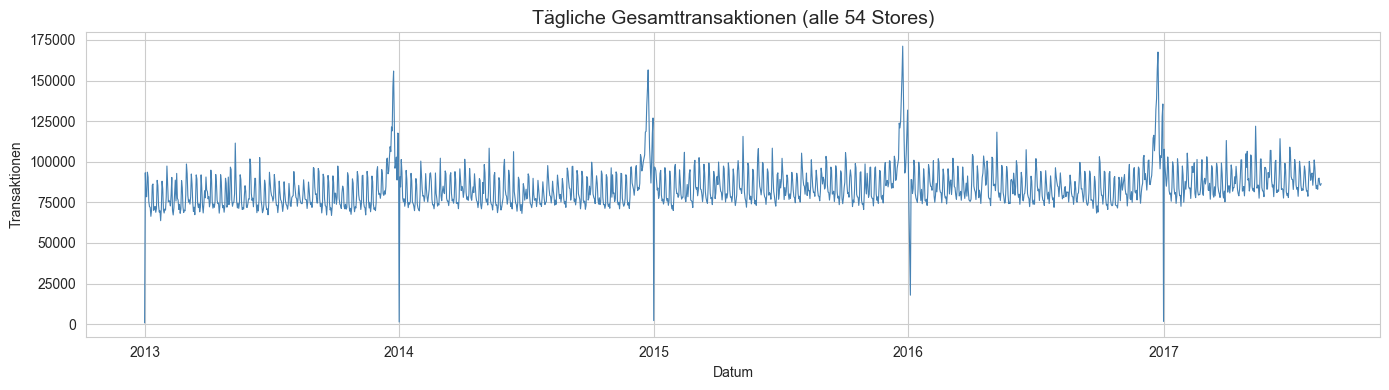

In [6]:
# Transaktionen über alle Stores im Zeitverlauf
daily_total = (
    tx.group_by('date')
    .agg(pl.col('transactions').sum().alias('total_transactions'))
    .sort('date')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total['date'], daily_total['total_transactions'], linewidth=0.8, color='steelblue')
ax.set_title('Tägliche Gesamttransaktionen (alle 54 Stores)', fontsize=14)
ax.set_xlabel('Datum')
ax.set_ylabel('Transaktionen')
plt.tight_layout()
plt.show()

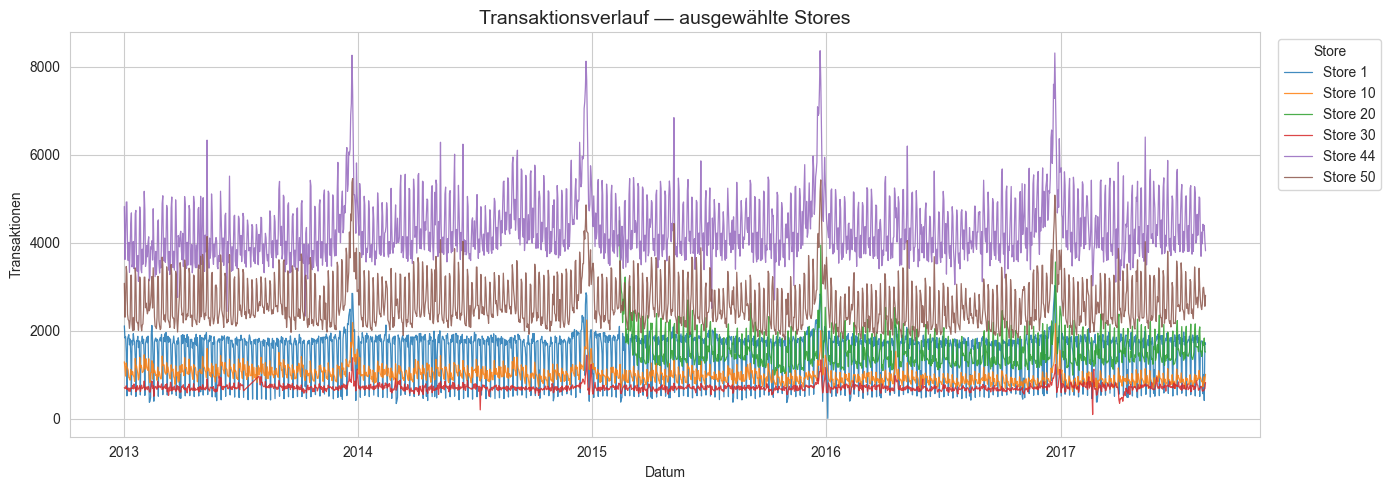

In [7]:
sample_stores = [1, 10, 20, 30, 44, 50]

tx_sample = (
    tx.filter(pl.col('store_nbr').is_in(sample_stores))
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(14, 5))
for store in sample_stores:
    d = tx_sample[tx_sample['store_nbr'] == store]
    ax.plot(d['date'], d['transactions'], label=f'Store {store}', linewidth=0.9, alpha=0.85)

ax.set_title('Transaktionsverlauf — ausgewählte Stores', fontsize=14)
ax.set_xlabel('Datum')
ax.set_ylabel('Transaktionen')
ax.legend(title='Store', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3 · stores.csv — Store-Metadaten

In [8]:
stores

store_nbr,city,state,type,cluster
i64,str,str,str,i64
1,"""Quito""","""Pichincha""","""D""",13
2,"""Quito""","""Pichincha""","""D""",13
3,"""Quito""","""Pichincha""","""D""",8
4,"""Quito""","""Pichincha""","""D""",9
5,"""Santo Domingo""","""Santo Domingo de los Tsachilas""","""D""",4
…,…,…,…,…
50,"""Ambato""","""Tungurahua""","""A""",14
51,"""Guayaquil""","""Guayas""","""A""",17
52,"""Manta""","""Manabi""","""A""",11


In [9]:
print('Store-Typen (A = groß, E = klein):')
print(stores['type'].value_counts().sort('type'))
print()
print('Cluster (Ähnlichkeitsgruppen):')
print(stores['cluster'].value_counts().sort('cluster'))
print()
print('Städte (Top 5):')
print(stores['city'].value_counts().head(5))

Store-Typen (A = groß, E = klein):
shape: (5, 2)
┌──────┬───────┐
│ type ┆ count │
│ ---  ┆ ---   │
│ str  ┆ u32   │
╞══════╪═══════╡
│ A    ┆ 9     │
│ B    ┆ 8     │
│ C    ┆ 15    │
│ D    ┆ 18    │
│ E    ┆ 4     │
└──────┴───────┘

Cluster (Ähnlichkeitsgruppen):
shape: (17, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 1       ┆ 3     │
│ 2       ┆ 2     │
│ 3       ┆ 7     │
│ 4       ┆ 3     │
│ 5       ┆ 1     │
│ …       ┆ …     │
│ 13      ┆ 4     │
│ 14      ┆ 4     │
│ 15      ┆ 5     │
│ 16      ┆ 1     │
│ 17      ┆ 1     │
└─────────┴───────┘

Städte (Top 5):
shape: (5, 2)
┌───────────────┬───────┐
│ city          ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ Ambato        ┆ 2     │
│ Santo Domingo ┆ 3     │
│ Quito         ┆ 18    │
│ Puyo          ┆ 1     │
│ Babahoyo      ┆ 1     │
└───────────────┴───────┘


C:\Users\maxkr\AppData\Local\Temp\ipykernel_18036\1180782398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_type, x='type', y='avg_transactions', palette='Blues_d', ax=ax)


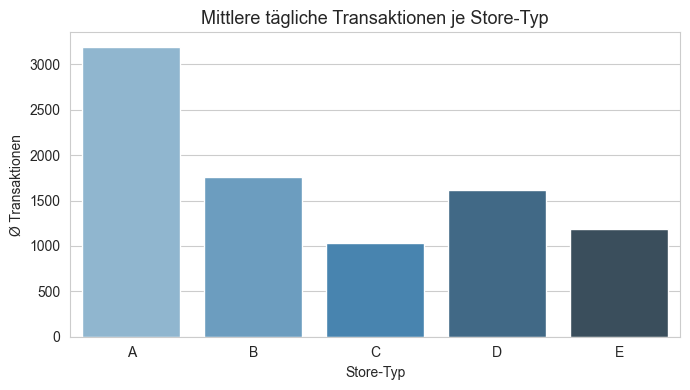

In [10]:
# Mittlere Transaktionen je Store-Typ
tx_with_meta = tx.join(stores, on='store_nbr', how='left')

avg_by_type = (
    tx_with_meta.group_by('type')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('type')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=avg_by_type, x='type', y='avg_transactions', palette='Blues_d', ax=ax)
ax.set_title('Mittlere tägliche Transaktionen je Store-Typ', fontsize=13)
ax.set_xlabel('Store-Typ')
ax.set_ylabel('Ø Transaktionen')
plt.tight_layout()
plt.show()

## 4 · oil.csv — Ölpreis als exogener Regressor

Ecuador ist eine ölexportierende Nation — der Ölpreis beeinflusst das verfügbare Einkommen und damit den Einzelhandel.

In [11]:
oil.head(10)

date,dcoilwtico
date,f64
2013-01-01,null
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.2
2013-01-08,93.21
2013-01-09,93.08
2013-01-10,93.81
2013-01-11,93.6


In [12]:
print('Null-Werte im Ölpreis:', oil['dcoilwtico'].null_count(), 'von', len(oil), 'Tagen')
print('(Wochenenden + Feiertage haben keinen Börsenkurs)')
print()
print(oil.describe())

Null-Werte im Ölpreis: 43 von 1218 Tagen
(Wochenenden + Feiertage haben keinen Börsenkurs)

shape: (9, 3)
┌────────────┬─────────────────────┬────────────┐
│ statistic  ┆ date                ┆ dcoilwtico │
│ ---        ┆ ---                 ┆ ---        │
│ str        ┆ str                 ┆ f64        │
╞════════════╪═════════════════════╪════════════╡
│ count      ┆ 1218                ┆ 1175.0     │
│ null_count ┆ 0                   ┆ 43.0       │
│ mean       ┆ 2015-05-02 12:00:00 ┆ 67.714366  │
│ std        ┆ null                ┆ 25.630476  │
│ min        ┆ 2013-01-01          ┆ 26.19      │
│ 25%        ┆ 2014-03-03          ┆ 46.41      │
│ 50%        ┆ 2015-05-04          ┆ 53.19      │
│ 75%        ┆ 2016-07-01          ┆ 95.71      │
│ max        ┆ 2017-08-31          ┆ 110.62     │
└────────────┴─────────────────────┴────────────┘


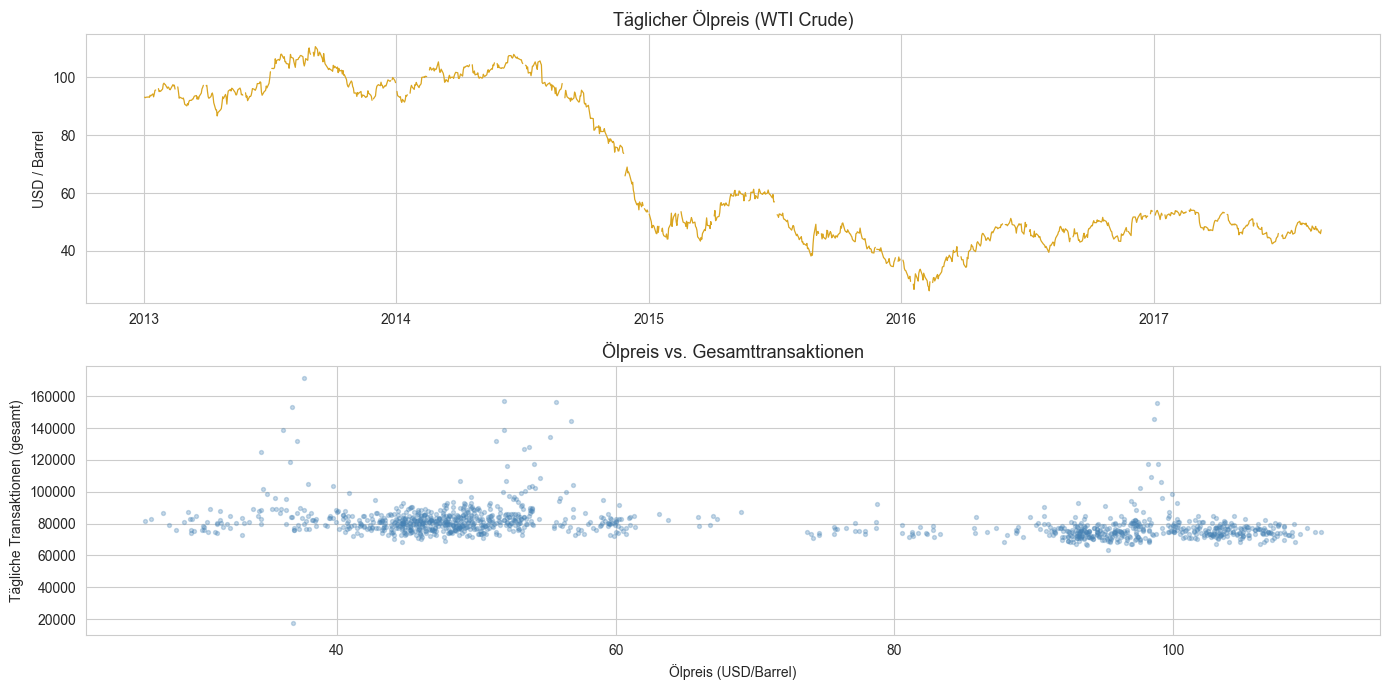

Pearson-Korrelation Ölpreis ↔ Transaktionen: -0.304


In [13]:
oil_pd = oil.to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Ölpreis Zeitverlauf
axes[0].plot(oil_pd['date'], oil_pd['dcoilwtico'], linewidth=0.9, color='goldenrod')
axes[0].set_title('Täglicher Ölpreis (WTI Crude)', fontsize=13)
axes[0].set_ylabel('USD / Barrel')

# Ölpreis vs. Gesamttransaktionen (merged auf gemeinsame Daten)
merged = daily_total.merge(oil_pd, on='date', how='inner').dropna()
axes[1].scatter(merged['dcoilwtico'], merged['total_transactions'],
                alpha=0.3, s=8, color='steelblue')
axes[1].set_title('Ölpreis vs. Gesamttransaktionen', fontsize=13)
axes[1].set_xlabel('Ölpreis (USD/Barrel)')
axes[1].set_ylabel('Tägliche Transaktionen (gesamt)')

plt.tight_layout()
plt.show()

corr = merged[['dcoilwtico', 'total_transactions']].corr().iloc[0, 1]
print(f'Pearson-Korrelation Ölpreis ↔ Transaktionen: {corr:.3f}')

## 5 · holidays_events.csv — Feiertage & Events

Drei Ebenen:
- **National** → gilt für alle 54 Stores
- **Regional** → gilt für Stores in der jeweiligen Region
- **Local** → gilt nur für Stores in der jeweiligen Stadt

Typen: `Holiday`, `Event`, `Additional`, `Transfer`, `Bridge`, `Work Day`

In [14]:
hol.head(15)

date,type,locale,locale_name,description,transferred
date,str,str,str,str,bool
2012-03-02,"""Holiday""","""Local""","""Manta""","""Fundacion de Manta""",false
2012-04-01,"""Holiday""","""Regional""","""Cotopaxi""","""Provincializacion de Cotopaxi""",false
2012-04-12,"""Holiday""","""Local""","""Cuenca""","""Fundacion de Cuenca""",false
2012-04-14,"""Holiday""","""Local""","""Libertad""","""Cantonizacion de Libertad""",false
2012-04-21,"""Holiday""","""Local""","""Riobamba""","""Cantonizacion de Riobamba""",false
…,…,…,…,…,…
2012-07-03,"""Holiday""","""Local""","""Santo Domingo""","""Fundacion de Santo Domingo""",false
2012-07-03,"""Holiday""","""Local""","""El Carmen""","""Cantonizacion de El Carmen""",false
2012-07-23,"""Holiday""","""Local""","""Cayambe""","""Cantonizacion de Cayambe""",false


In [15]:
print('Feiertags-Typen:')
print(hol['type'].value_counts().sort('type'))
print()
print('Locale-Ebenen:')
print(hol['locale'].value_counts())
print()
print('Transferred = True (Feiertag wurde verschoben):')
print(hol.filter(pl.col('transferred') == True))

Feiertags-Typen:
shape: (6, 2)
┌────────────┬───────┐
│ type       ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Additional ┆ 51    │
│ Bridge     ┆ 5     │
│ Event      ┆ 56    │
│ Holiday    ┆ 221   │
│ Transfer   ┆ 12    │
│ Work Day   ┆ 5     │
└────────────┴───────┘

Locale-Ebenen:
shape: (3, 2)
┌──────────┬───────┐
│ locale   ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ National ┆ 174   │
│ Local    ┆ 152   │
│ Regional ┆ 24    │
└──────────┴───────┘

Transferred = True (Feiertag wurde verschoben):
shape: (12, 6)
┌────────────┬─────────┬──────────┬─────────────┬───────────────────────────────┬─────────────┐
│ date       ┆ type    ┆ locale   ┆ locale_name ┆ description                   ┆ transferred │
│ ---        ┆ ---     ┆ ---      ┆ ---         ┆ ---                           ┆ ---         │
│ date       ┆ str     ┆ str      ┆ str         ┆ str                           ┆ bool        │
╞════════════╪═════════╪══

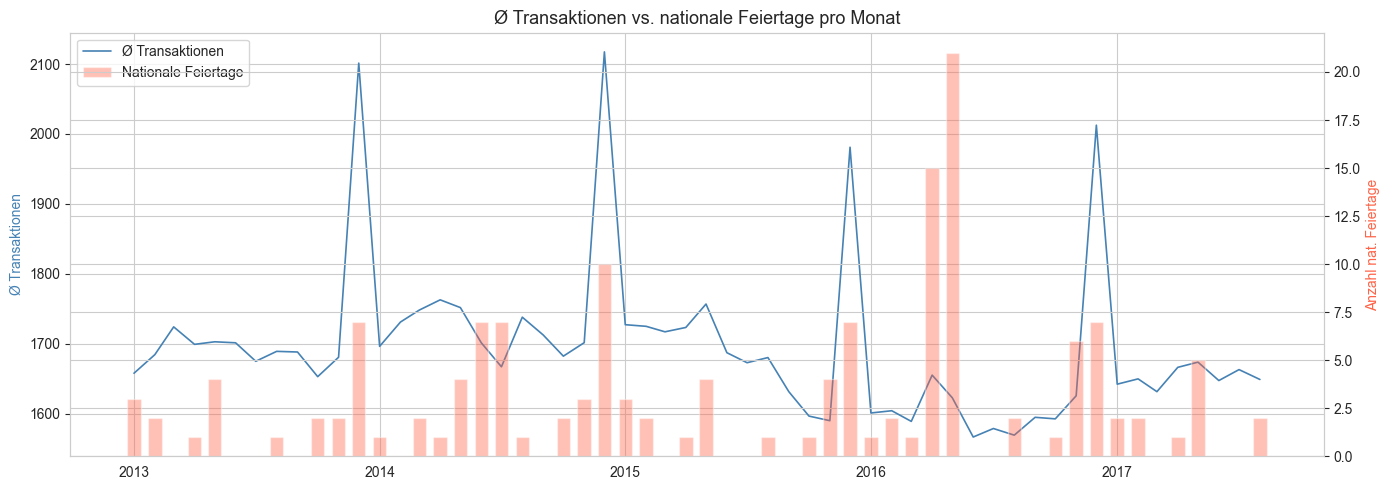

In [16]:
hol_national = (
    hol.filter(pl.col('locale') == 'National')
    .with_columns(pl.col('date').dt.truncate('1mo').alias('month'))
    .group_by('month')
    .agg(pl.len().alias('n_holidays'))
    .sort('month')
    .to_pandas()
)

tx_monthly = (
    tx.with_columns(pl.col('date').dt.truncate('1mo').alias('month'))
    .group_by('month')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('month')
    .to_pandas()
)

merged_hol = tx_monthly.merge(hol_national, on='month', how='left').fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(merged_hol['month'], merged_hol['avg_transactions'],
         color='steelblue', linewidth=1.2, label='Ø Transaktionen')
ax2.bar(merged_hol['month'], merged_hol['n_holidays'],
        color='tomato', alpha=0.4, width=20, label='Nationale Feiertage')

ax1.set_title('Ø Transaktionen vs. nationale Feiertage pro Monat', fontsize=13)
ax1.set_ylabel('Ø Transaktionen', color='steelblue')
ax2.set_ylabel('Anzahl nat. Feiertage', color='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## 6 · Saisonalität — Wochentag & Monat

C:\Users\maxkr\AppData\Local\Temp\ipykernel_18036\4190142643.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_weekday, x='weekday', y='avg', palette='Blues_d', ax=axes[0])
C:\Users\maxkr\AppData\Local\Temp\ipykernel_18036\4190142643.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_month, x='month', y='avg', palette='Blues_d', ax=axes[1])


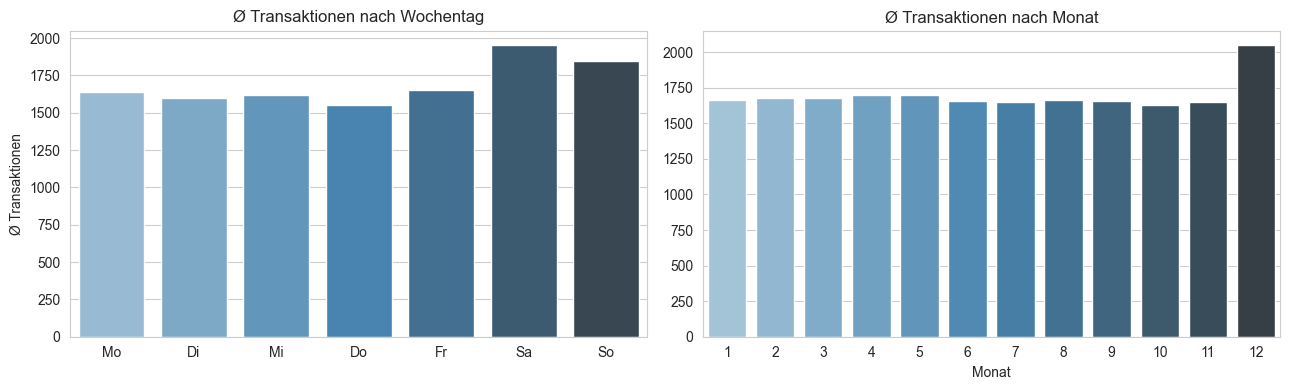

In [17]:
tx_season = tx.with_columns([
    pl.col('date').dt.weekday().alias('weekday'),   # 0 = Montag, 6 = Sonntag
    pl.col('date').dt.month().alias('month'),
])

avg_weekday = (
    tx_season.group_by('weekday')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('weekday')
    .to_pandas()
)

avg_month = (
    tx_season.group_by('month')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('month')
    .to_pandas()
)

weekday_labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=avg_weekday, x='weekday', y='avg', palette='Blues_d', ax=axes[0])
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(weekday_labels)
axes[0].set_title('Ø Transaktionen nach Wochentag', fontsize=12)
axes[0].set_ylabel('Ø Transaktionen')
axes[0].set_xlabel('')

sns.barplot(data=avg_month, x='month', y='avg', palette='Blues_d', ax=axes[1])
axes[1].set_title('Ø Transaktionen nach Monat', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_xlabel('Monat')

plt.tight_layout()
plt.show()

## 7 · Qualitäts-Check — fehlende Tage & Ausreißer

In [18]:
# Fehlende Tage: Erwartetes Kreuzprodukt (alle Tage × alle Stores)
all_dates = tx.select('date').unique()
all_stores = tx.select('store_nbr').unique()

full_grid = all_dates.join(all_stores, how='cross')
missing = full_grid.join(tx, on=['date', 'store_nbr'], how='anti')

print(f'Fehlende Store-Tag-Kombinationen: {len(missing):,}')
print(f'(von {len(full_grid):,} möglichen = {len(missing)/len(full_grid)*100:.1f}%)')
print()

# Welche Stores haben die meisten fehlenden Tage?
missing_by_store = (
    missing.group_by('store_nbr')
    .agg(pl.len().alias('missing_days'))
    .sort('missing_days', descending=True)
    .head(10)
)
print('Top-10 Stores mit den meisten fehlenden Tagen:')
print(missing_by_store)

Fehlende Store-Tag-Kombinationen: 7,340
(von 90,828 möglichen = 8.1%)

Top-10 Stores mit den meisten fehlenden Tagen:
shape: (10, 2)
┌───────────┬──────────────┐
│ store_nbr ┆ missing_days │
│ ---       ┆ ---          │
│ i64       ┆ u32          │
╞═══════════╪══════════════╡
│ 52        ┆ 1564         │
│ 22        ┆ 1011         │
│ 42        ┆ 962          │
│ 21        ┆ 934          │
│ 29        ┆ 808          │
│ 20        ┆ 773          │
│ 53        ┆ 515          │
│ 36        ┆ 131          │
│ 18        ┆ 116          │
│ 24        ┆ 105          │
└───────────┴──────────────┘


In [19]:
# Ausreißer-Check: Transaktionen > 3 Std.-Abweichungen vom Store-Mittel
stats = (
    tx.group_by('store_nbr')
    .agg([
        pl.col('transactions').mean().alias('mean'),
        pl.col('transactions').std().alias('std')
    ])
)

outliers = (
    tx.join(stats, on='store_nbr')
    .with_columns(
        ((pl.col('transactions') - pl.col('mean')) / pl.col('std')).alias('z_score')
    )
    .filter(pl.col('z_score').abs() > 3)
    .sort('z_score', descending=True)
)

print(f'Ausreißer (|z| > 3): {len(outliers)} Einträge')
outliers.head(15)

Ausreißer (|z| > 3): 1002 Einträge


date,store_nbr,transactions,mean,std,z_score
date,i64,i64,f64,f64,f64
2015-10-09,22,2412,751.350224,144.880531,11.462201
2015-05-29,12,2363,1212.160891,118.067704,9.747281
2015-12-24,2,4060,1920.036374,226.496662,9.448102
2013-12-24,23,2236,1066.291592,126.724276,9.230342
2014-12-24,5,3468,1400.045915,225.305906,9.178428
…,…,…,…,…,…
2013-12-24,5,3316,1400.045915,225.305906,8.50379
2015-12-31,31,3489,1374.281287,248.737999,8.501792
2015-12-24,4,3434,1502.98747,228.510746,8.450423


## 8 · Datensatz wegschreiben

In [20]:
PROCESSED = Path('..') / '02_data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

tx.write_parquet(PROCESSED / 'transactions.parquet')

# Store-Metadaten
stores.write_parquet(PROCESSED / 'stores.parquet')

# Ölpreis (NaN-Werte werden in Feature Engineering interpoliert)
oil.write_parquet(PROCESSED / 'oil.parquet')

# Feiertage
hol.write_parquet(PROCESSED / 'holidays.parquet')

# Transactions + Store-Metadaten (praktischer Arbeits-Datensatz)
tx_enriched = tx.join(stores, on='store_nbr', how='left')
tx_enriched.write_parquet(PROCESSED / 'transactions_with_store_meta.parquet')

print('Gespeichert:')
for f in sorted(PROCESSED.glob('*.parquet')):
    print(f'  {f.name}')

Gespeichert:
  daily_avg_all_stores.parquet
  holidays.parquet
  oil.parquet
  stores.parquet
  transactions.parquet
  transactions_long.parquet
  transactions_with_store_meta.parquet
